# Eye-Tracking Data Evaluation

Gaze data collected with GazePoint GP3 HD (60 Hz, binocular) on a 1920×1080 display (33.8×27.1 cm, 57 cm viewing distance). The experiment presents pairs of images side-by-side. Each trial follows the sequence:

```
FIXATION_POINT_START → FIXATION_POINT_END → STIMULUS_ONSET → IMAGE_OFFSET
```

This notebook covers:
1. Trial segmentation from raw TSV markers
2. Scanpath visualization per trial
3. Fixation cross accuracy & precision
4. Gaze trajectory over time (t–x plot)
5. Stimulus randomization check

---
## 1. Data Loading & Trial Segmentation


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

path = '../data/subject-3'

df = pd.read_csv(path + ".tsv", sep='\t')
df.replace(['NA', 'undefined'], np.nan, inplace=True)
df['TIME']  = pd.to_numeric(df['TIME'],  errors='coerce')
df['dx']    = pd.to_numeric(df['FPOGX'], errors='coerce')
df['dy']    = pd.to_numeric(df['FPOGY'], errors='coerce')
df['FPOGV'] = pd.to_numeric(df['FPOGV'], errors='coerce')
df = df.dropna(subset=['dx', 'dy']).sort_values('TIME').reset_index(drop=True)

csv = pd.read_csv(path + ".csv")
csv = csv[csv['trial_nr'].notna() & (csv['trial_nr'] != 'trial_nr')].reset_index(drop=True)
csv['trial_nr'] = pd.to_numeric(csv['trial_nr'], errors='coerce')
csv = csv.dropna(subset=['trial_nr']).reset_index(drop=True)

# Extract timing markers
fix_starts  = df[df['USER'].notna() & df['USER'].str.contains('FIXATION_POINT_START', na=False)]['TIME'].values
fix_ends    = df[df['USER'].notna() & df['USER'].str.contains('FIXATION_POINT_END',   na=False)]['TIME'].values
onsets      = df[df['USER'].notna() & df['USER'].str.contains('STIMULUS_ONSET',        na=False)].copy()
img_offsets = df[df['USER'].notna() & df['USER'].str.contains('IMAGE_OFFSET',          na=False)]['TIME'].values

onset_times = onsets['TIME'].values

# Build per-trial fixation cross windows: FIXATION_POINT_START → FIXATION_POINT_END
# (pair each fix_start with the next fix_end that precedes the corresponding STIMULUS_ONSET)
fix_windows = []
for t0 in onset_times:
    starts_before = fix_starts[fix_starts < t0]
    ends_before   = fix_ends[fix_ends   < t0]
    t_fs = starts_before[-1] if len(starts_before) else np.nan
    t_fe = ends_before[-1]   if len(ends_before)   else np.nan
    # if no FIXATION_POINT_END found for this trial, use STIMULUS_ONSET as fallback end
    fix_windows.append((t_fs, t_fe if (not np.isnan(t_fe) and t_fe > t_fs) else t0))

# Build per-trial image segments: STIMULUS_ONSET → IMAGE_OFFSET
segments = []
for i, (_, row) in enumerate(onsets.iterrows()):
    t0 = row['TIME']
    offsets_after = img_offsets[img_offsets > t0]
    t_end = offsets_after[0] if len(offsets_after) else t0 + 10.0

    seg = df[(df['TIME'] >= t0) & (df['TIME'] <= t_end) & (df['FPOGV'] == 1) &
             (df['dx'] >= 0) & (df['dx'] <= 1) & (df['dy'] >= 0) & (df['dy'] <= 1)].copy()
    seg['t_rel'] = seg['TIME'] - t0

    label     = row['USER'].strip()
    img_left  = label.split('IMG_LEFT=')[1].split(' ')[0]  if 'IMG_LEFT='  in label else '?'
    img_right = label.split('IMG_RIGHT=')[1].split(' ')[0] if 'IMG_RIGHT=' in label else '?'

    r  = csv.iloc[i]
    lx = int(960 + r['x_left']);  ly = int(540 + r['y_left'])
    rx = int(960 + r['x_right']); ry = int(540 + r['y_right'])
    segments.append({'seg': seg, 'img_left': img_left, 'img_right': img_right,
                     'left_px': (lx, ly), 'right_px': (rx, ry),
                     'csv_side': r['first_fix_side'], 'csv_rt': r['first_fix_rt'],
                     't0': t0, 't_end': t_end,
                     'fix_start': fix_windows[i][0], 'fix_end': fix_windows[i][1]})

print(f'{len(segments)} trials loaded')
for i, s in enumerate(segments):
    fs, fe = s['fix_start'], s['fix_end']
    print(f"  trial {i+1}: fix [{fs:.3f}–{fe:.3f}]  img [{s['t0']:.3f}–{s['t_end']:.3f}]  "
          f"({len(s['seg'])} gaze samples)")


8 trials loaded
  trial 1: fix [2731.926–2733.440]  img [2734.585–2737.599]  (388 gaze samples)
  trial 2: fix [2742.529–2744.043]  img [2745.061–2749.576]  (561 gaze samples)
  trial 3: fix [2751.538–2753.052]  img [2754.063–2757.239]  (353 gaze samples)
  trial 4: fix [2760.882–2762.396]  img [2763.407–2766.730]  (407 gaze samples)
  trial 5: fix [2770.300–2771.814]  img [2772.825–2776.630]  (494 gaze samples)
  trial 6: fix [2779.798–2781.305]  img [2782.316–2785.545]  (393 gaze samples)
  trial 7: fix [2789.450–2790.964]  img [2791.975–2795.057]  (395 gaze samples)
  trial 8: fix [2803.389–2804.159]  img [2805.171–2808.179]  (387 gaze samples)


Each trial's fixation window (`FIXATION_POINT_START` → `FIXATION_POINT_END`) and image display window (`STIMULUS_ONSET` → `IMAGE_OFFSET`) are extracted and verified. Trials missing `FIXATION_POINT_END` fall back to `STIMULUS_ONSET` as the window end.

---
## 2. Scanpath per Trial

Gaze trajectories plotted in screen space (1920×1080 px) for each trial. Color progresses **purple → yellow** (plasma colormap) over time. The **white dot** marks the first gaze sample; earlier samples are drawn on top of later ones so the initial fixation direction remains clearly visible. Blue/red squares indicate the left/right image positions.


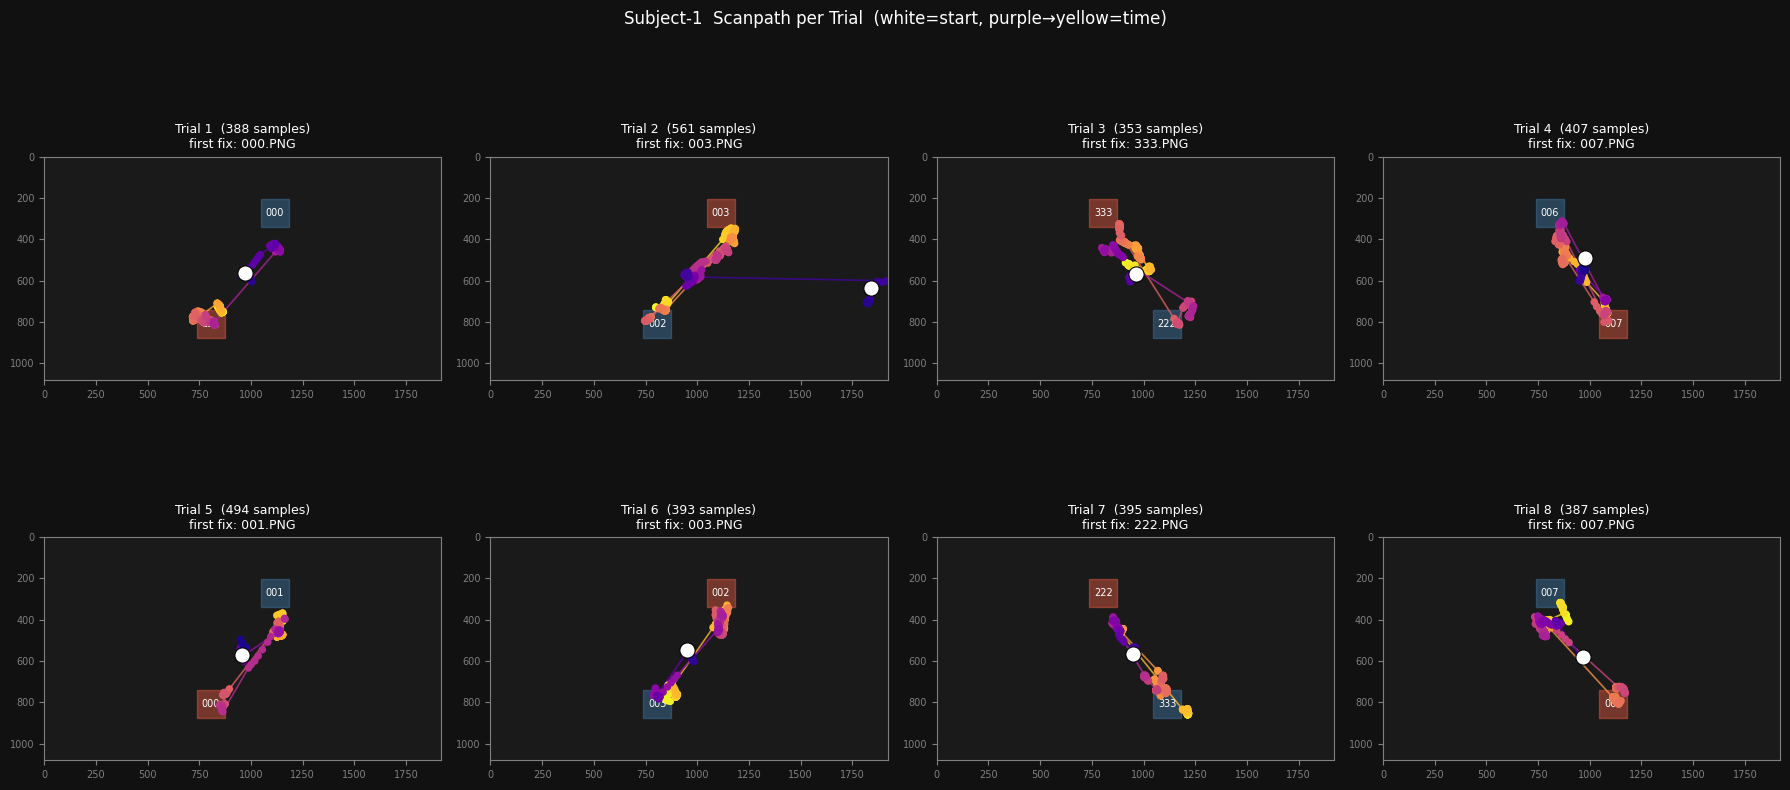

In [20]:
SCREEN_W, SCREEN_H = 1920, 1080

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, trial in enumerate(segments):
    ax  = axes[i // 4, i % 4]
    seg = trial['seg']
    lx, ly = trial['left_px']
    rx, ry = trial['right_px']

    ax.set_xlim(0, SCREEN_W)
    ax.set_ylim(SCREEN_H, 0)
    ax.set_facecolor('#1a1a1a')
    ax.set_aspect('equal')

    ax.scatter([lx], [ly], s=400, marker='s', color='steelblue', alpha=0.4, zorder=1, label=f'L:{trial["img_left"]}')
    ax.scatter([rx], [ry], s=400, marker='s', color='tomato',    alpha=0.4, zorder=1, label=f'R:{trial["img_right"]}')
    ax.text(lx, ly, trial['img_left'].replace('.PNG',''),  ha='center', va='center', fontsize=7, color='white')
    ax.text(rx, ry, trial['img_right'].replace('.PNG',''), ha='center', va='center', fontsize=7, color='white')

    if len(seg) >= 2:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        n  = len(xs)
        colors_arr = cm.plasma(np.linspace(0, 1, n))

        # Draw from last to first so earlier lines/dots render on top
        for j in range(n - 2, -1, -1):
            ax.plot([xs[j], xs[j+1]], [ys[j], ys[j+1]], color=colors_arr[j], lw=1.2, alpha=0.8)
        for j in range(n - 1, 0, -1):
            ax.scatter([xs[j]], [ys[j]], color=colors_arr[j], s=30, zorder=5, edgecolors='none')

        # First point: white circle on top
        ax.scatter([xs[0]], [ys[0]], s=120, color='white', zorder=7, edgecolors='black', linewidths=0.8)

    elif len(seg) == 1:
        xs = seg['dx'].values * SCREEN_W
        ys = seg['dy'].values * SCREEN_H
        ax.scatter(xs, ys, s=120, color='white', zorder=7, edgecolors='black', linewidths=0.8)

    first_img = 'unclear'
    if len(seg) >= 1:
        for xi, yi in zip(seg['dx'].values * SCREEN_W, seg['dy'].values * SCREEN_H):
            dl = np.hypot(xi - lx, yi - ly)
            dr = np.hypot(xi - rx, yi - ry)
            if abs(dl - dr) > 100:
                first_img = trial['img_left'] if dl < dr else trial['img_right']
                break

    ax.set_title(f'Trial {i+1}  ({len(seg)} samples)\nfirst fix: {first_img}',
                 fontsize=9, color='white')
    ax.tick_params(colors='gray', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')

fig.patch.set_facecolor('#111111')
plt.suptitle('Subject-1  Scanpath per Trial  (white=start, purple→yellow=time)',
             fontsize=12, color='white')
plt.tight_layout()
plt.show()


The title of each panel reports the first-fixated image, determined by the first gaze sample that falls closer to one image than the other by more than 100 px. Trials with few samples may reflect a brief or absent fixation during the viewing window.

---
## 3. Trial Marker Timeline

USER markers in the raw TSV are counted to confirm all expected events are present. Per-trial image display durations are computed as the interval from `STIMULUS_ONSET` to `IMAGE_OFFSET`.


In [21]:
# --- Trigger count and per-trial image display duration ---
markers = df[df['USER'].notna() & (df['USER'] != '0')].copy()
print("Marker counts:")
print(markers['USER'].value_counts().to_string())

print("\nPer-trial timing:")
print(f"{'trial':<8} {'t_onset':>10} {'duration(s)':>12}")
for i, s in enumerate(segments):
    print(f"trial {i+1:<3} {s['t0']:>10.3f} {s['t_end'] - s['t0']:>12.3f}")


Marker counts:
USER
FIXATION_POINT_START                                                                      8
FIXATION_POINT_END                                                                        8
IMAGE_OFFSET                                                                              8
START_TRIAL                                                                               1
MSG FIXATION_ONSET TRIAL=1 GROUP=LTR                                                      1
MSG STIMULUS_ONSET TRIAL=1 IMG_LEFT=000.PNG IMG_RIGHT=111.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG FIXATION_ONSET TRIAL=2 GROUP=LTR                                                      1
MSG STIMULUS_ONSET TRIAL=2 IMG_LEFT=002.PNG IMG_RIGHT=003.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG FIXATION_ONSET TRIAL=3 GROUP=LTR                                                      1
MSG STIMULUS_ONSET TRIAL=3 IMG_LEFT=222.PNG IMG_RIGHT=333.PNG GROUP=LTR PRIME_LANG=LTR    1
MSG FIXATION_ONSET TRIAL=4 GROUP=LTR                        

All expected markers should appear exactly once per trial. Trials with unusually long display durations may indicate a delayed or absent first-fixation response — cross-reference with `first_fix_rt` in the behavioral CSV.

---
## 4. Fixation Cross Accuracy & Precision

During `FIXATION_POINT_START` → `FIXATION_POINT_END`, the participant should fixate screen center. Gaze quality is quantified in **degrees of visual angle** using the display geometry recorded in the calibration log (viewing distance 57 cm; screen 33.8×27.1 cm).

| Metric | Formula | What it captures |
|---|---|---|
| **Accuracy X / Y** | mean \|offset°\| per axis | Directional bias (e.g. systematic left shift) |
| **Accuracy Total** | mean Euclidean offset° | Overall angular error from target |
| **Precision RMS-S2S** | √ mean(Δx°² + Δy°²) | High-frequency noise between consecutive samples |
| **Precision SD** | √(σ_x°² + σ_y°²) | Spatial spread; robust to embedded microsaccades |


Fixation cross period — accuracy & precision (degrees of visual angle):
 trial   n  has_fix_end    acc_x    acc_y  acc_total  prec_rms  prec_sd
     1 201         True 1.524178 0.642406   1.841894  0.459470 2.436203
     2 184         True 0.359629 1.012863   1.108402  0.107088 0.547045
     3 208         True 0.523788 0.639736   0.921899  0.161413 0.697146
     4 209         True 0.229183 1.001383   1.045404  0.183131 0.525450
     5 179         True 0.404833 1.054957   1.155558  0.184569 0.827794
     6 220         True 0.247199 0.847526   0.897273  0.078623 0.382756
     7 185         True 0.190015 0.819480   0.869361  0.166105 0.464097
     8  98         True 4.333211 1.576080   5.070269  0.932998 4.999099

* trials without FIXATION_POINT_END: STIMULUS_ONSET used as fallback end


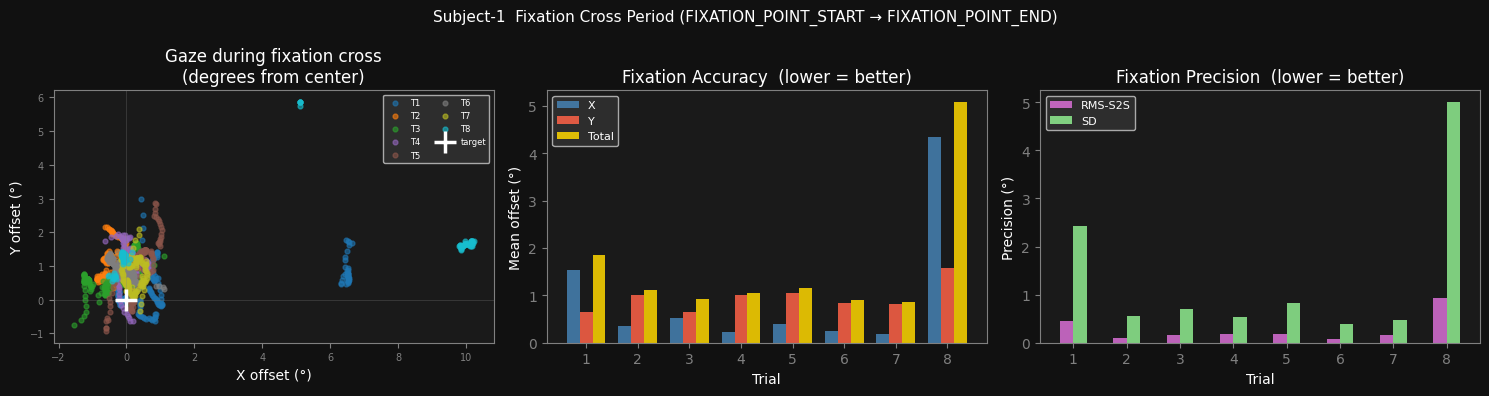

In [22]:
# --- Fixation cross accuracy & precision ---
# Period: FIXATION_POINT_START → FIXATION_POINT_END per trial
SCREEN_W, SCREEN_H = 1920, 1080
CX, CY = SCREEN_W / 2, SCREEN_H / 2

# Display geometry from pygaze calibration log
VIEWING_DIST_CM = 57.0
CM_PER_PX_X = 33.8 / SCREEN_W   # horizontal cm per pixel
CM_PER_PX_Y = 27.1 / SCREEN_H   # vertical cm per pixel

def px_offset_to_deg(px_x, px_y):
    """
    Convert pixel offsets from fixation target to degrees of visual angle.
    X and Y are converted independently because horizontal and vertical
    pixel densities differ (33.8cm/1920px vs 27.1cm/1080px).
    Formula: arctan(offset_cm / viewing_distance_cm)
    """
    return (np.degrees(np.arctan2(px_x * CM_PER_PX_X, VIEWING_DIST_CM)),
            np.degrees(np.arctan2(px_y * CM_PER_PX_Y, VIEWING_DIST_CM)))

fix_stats = []
for i, s in enumerate(segments):
    t_fs, t_fe = s['fix_start'], s['fix_end']
    has_end = not np.isnan(t_fe) and t_fe < s['t0']

    if np.isnan(t_fs):
        fix_stats.append({'trial': i+1, 'n': 0, 'has_fix_end': False,
                          'acc_x': np.nan, 'acc_y': np.nan, 'acc_total': np.nan,
                          'prec_rms': np.nan, 'prec_sd': np.nan})
        continue

    fdata = df[(df['TIME'] >= t_fs) & (df['TIME'] <= t_fe) & (df['FPOGV'] == 1) &
               (df['dx'] >= 0) & (df['dx'] <= 1) & (df['dy'] >= 0) & (df['dy'] <= 1)]

    if len(fdata) < 2:
        fix_stats.append({'trial': i+1, 'n': len(fdata), 'has_fix_end': has_end,
                          'acc_x': np.nan, 'acc_y': np.nan, 'acc_total': np.nan,
                          'prec_rms': np.nan, 'prec_sd': np.nan})
        continue

    gx_deg, gy_deg = px_offset_to_deg(
        fdata['dx'].values * SCREEN_W - CX,
        fdata['dy'].values * SCREEN_H - CY)

    # Accuracy: mean angular offset from fixation target (screen center = 0°, 0°).
    # X and Y reported separately to detect directional bias (e.g. systematic left/right shift).
    # Total is the mean Euclidean distance in degree space.
    acc_x     = np.abs(gx_deg).mean()
    acc_y     = np.abs(gy_deg).mean()
    acc_total = np.hypot(gx_deg, gy_deg).mean()

    # Precision — two complementary measures (both in degrees):
    #
    # RMS-S2S (Root Mean Square of Sample-to-Sample displacement):
    #   sqrt( mean( Δx_deg² + Δy_deg² ) ) over consecutive samples.
    #   Captures high-frequency noise; standard metric used by GazePoint, Tobii, SR Research.
    #   Sensitive to microsaccades embedded in the fixation period.
    prec_rms = np.sqrt(np.mean(np.diff(gx_deg)**2 + np.diff(gy_deg)**2))

    # SD (combined spatial standard deviation):
    #   sqrt( std(x_deg)² + std(y_deg)² )
    #   Measures overall spatial spread of gaze around its mean position.
    #   More robust than RMS-S2S when microsaccades are present,
    #   because it is not inflated by individual large inter-sample jumps.
    prec_sd = np.sqrt(np.std(gx_deg)**2 + np.std(gy_deg)**2)

    fix_stats.append({'trial': i+1, 'n': len(fdata), 'has_fix_end': has_end,
                      'acc_x': acc_x, 'acc_y': acc_y, 'acc_total': acc_total,
                      'prec_rms': prec_rms, 'prec_sd': prec_sd})

fix_df = pd.DataFrame(fix_stats)
print("Fixation cross period — accuracy & precision (degrees of visual angle):")
print(fix_df.to_string(index=False))
print("\n* trials without FIXATION_POINT_END: STIMULUS_ONSET used as fallback end")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
trial_colors = cm.tab10(np.linspace(0, 1, len(segments)))

# Panel 1: spatial scatter in degrees from fixation target
ax = axes[0]
ax.set_facecolor('#1a1a1a')
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
for i, s in enumerate(segments):
    t_fs, t_fe = s['fix_start'], s['fix_end']
    if np.isnan(t_fs):
        continue
    fdata = df[(df['TIME'] >= t_fs) & (df['TIME'] <= t_fe) & (df['FPOGV'] == 1) &
               (df['dx'] >= 0) & (df['dx'] <= 1) & (df['dy'] >= 0) & (df['dy'] <= 1)]
    if len(fdata):
        gx, gy = px_offset_to_deg(fdata['dx'].values * SCREEN_W - CX,
                                   fdata['dy'].values * SCREEN_H - CY)
        ax.scatter(gx, gy, s=12, alpha=0.6, color=trial_colors[i], label=f'T{i+1}')
ax.scatter([0], [0], s=250, marker='+', color='white', linewidths=2.5, zorder=10, label='target')
ax.set_title('Gaze during fixation cross\n(degrees from center)', color='white')
ax.set_xlabel('X offset (°)', color='white')
ax.set_ylabel('Y offset (°)', color='white')
ax.tick_params(colors='gray', labelsize=7)
for sp in ax.spines.values(): sp.set_edgecolor('gray')
ax.legend(facecolor='#333333', labelcolor='white', fontsize=6, ncol=2)

# Panel 2: accuracy per trial (X, Y, total)
ax = axes[1]
x, w = fix_df['trial'].values, 0.25
ax.bar(x - w, fix_df['acc_x'],     width=w, color='steelblue', alpha=0.85, label='X')
ax.bar(x,     fix_df['acc_y'],     width=w, color='tomato',    alpha=0.85, label='Y')
ax.bar(x + w, fix_df['acc_total'], width=w, color='gold',      alpha=0.85, label='Total')
ax.set_xlabel('Trial', color='white')
ax.set_ylabel('Mean offset (°)', color='white')
ax.set_title('Fixation Accuracy  (lower = better)', color='white')
ax.set_facecolor('#1a1a1a'); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('gray')
ax.legend(facecolor='#333333', labelcolor='white', fontsize=8)

# Panel 3: precision per trial (RMS-S2S vs SD)
ax = axes[2]
ax.bar(x - w/2, fix_df['prec_rms'], width=w, color='orchid',     alpha=0.85, label='RMS-S2S')
ax.bar(x + w/2, fix_df['prec_sd'],  width=w, color='lightgreen', alpha=0.85, label='SD')
ax.set_xlabel('Trial', color='white')
ax.set_ylabel('Precision (°)', color='white')
ax.set_title('Fixation Precision  (lower = better)', color='white')
ax.set_facecolor('#1a1a1a'); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('gray')
ax.legend(facecolor='#333333', labelcolor='white', fontsize=8)

fig.patch.set_facecolor('#111111')
plt.suptitle('Subject-1  Fixation Cross Period (FIXATION_POINT_START → FIXATION_POINT_END)',
             fontsize=11, color='white')
plt.tight_layout()
plt.show()


Trials with elevated accuracy error or precision, or with a markedly lower sample count, may indicate a blink or brief tracker loss during the fixation window. When RMS-S2S is noticeably higher than SD for the same trial, microsaccades during the fixation period are the likely cause. Such trials should be flagged in any quality-based exclusion step.

---
## 5. Gaze Trajectory over Time (t–x plot)

X-gaze position as a function of time, aligned to `STIMULUS_ONSET` (t = 0). Horizontal dashed lines mark the physical screen positions of the images (960 ± 154 px). Each trace ends at `IMAGE_OFFSET`. The direction and latency of the first deflection from center indicate which image was fixated first and how quickly.


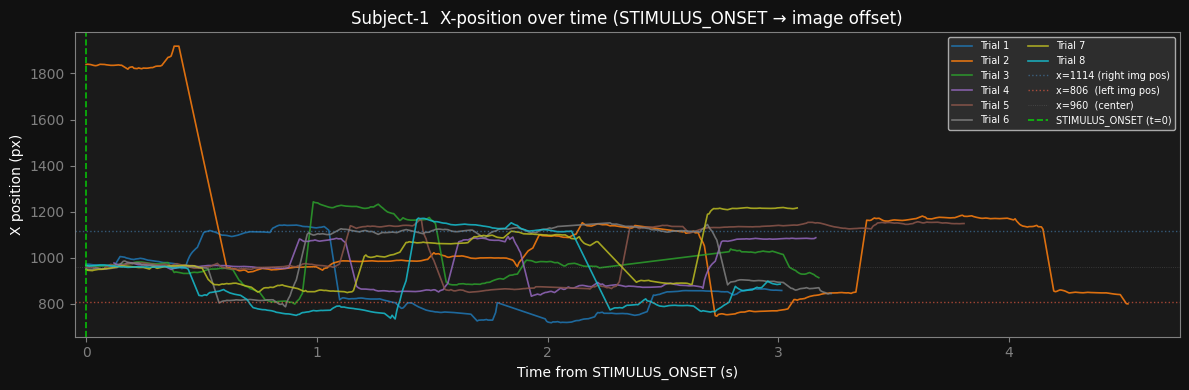

In [23]:
# --- Time vs X-position: STIMULUS_ONSET (image on) to image offset (next onset) ---
fig, ax = plt.subplots(figsize=(12, 4))

trial_colors = cm.tab10(np.linspace(0, 1, len(segments)))

for i, trial in enumerate(segments):
    seg = trial['seg']
    if len(seg) == 0:
        continue
    ax.plot(seg['t_rel'], seg['dx'] * SCREEN_W,
            color=trial_colors[i], lw=1.2, alpha=0.85, label=f'Trial {i+1}')

# Physical image x-positions (counterbalanced: 960±154px)
ax.axhline(960 + 154, color='steelblue', ls=':', lw=1.0, alpha=0.6, label='x=1114 (right img pos)')
ax.axhline(960 - 154, color='tomato',    ls=':', lw=1.0, alpha=0.6, label='x=806  (left img pos)')
ax.axhline(960,       color='gray',      ls=':', lw=0.6, alpha=0.4, label='x=960  (center)')
ax.axvline(0, color='lime', lw=1.2, ls='--', alpha=0.7, label='STIMULUS_ONSET (t=0)')

ax.set_xlabel('Time from STIMULUS_ONSET (s)', color='white')
ax.set_ylabel('X position (px)', color='white')
ax.set_xlim(-0.05, None)
ax.set_facecolor('#1a1a1a')
ax.tick_params(colors='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.legend(facecolor='#333333', labelcolor='white', fontsize=7, ncol=2)

fig.patch.set_facecolor('#111111')
plt.title('Subject-1  X-position over time (STIMULUS_ONSET → image offset)', color='white')
plt.tight_layout()
plt.show()


Traces that stay near the center line (960 px) throughout suggest the participant did not make a clear lateral saccade during the viewing window. Traces settling near 806 px or 1114 px indicate sustained fixation on the left or right image, respectively.

---
## 6. Stimulus Randomization Check

Verification that (1) each image appears the expected number of times across trials, and (2) left/right screen positions are correctly counterbalanced.


In [24]:
# --- Balancing / randomization check ---
print("Image appearance count (each image should appear exactly twice):")
from collections import Counter
all_imgs = list(csv['img_left']) + list(csv['img_right'])
for img, n in sorted(Counter(all_imgs).items()):
    print(f"  {img}: {n}")

print("\nLeft/right position counterbalancing (x_left sign per trial):")
for _, r in csv.iterrows():
    side = 'img_left=RIGHT, img_right=LEFT' if r['x_left'] > 0 else 'img_left=LEFT,  img_right=RIGHT'
    print(f"  trial {r['trial_nr']}: {side}  (x_left={r['x_left']})")

print("\nImage pair assignments:")
for _, r in csv.iterrows():
    print(f"  trial {r['trial_nr']}: {r['img_left']} vs {r['img_right']}")

Image appearance count (each image should appear exactly twice):
  000.png: 2
  001.png: 1
  002.png: 2
  003.png: 2
  006.png: 2
  007.png: 2
  111.png: 1
  222.png: 2
  333.png: 2

Left/right position counterbalancing (x_left sign per trial):
  trial 1: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 2: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 3: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 4: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 5: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 6: img_left=LEFT,  img_right=RIGHT  (x_left=-154)
  trial 7: img_left=RIGHT, img_right=LEFT  (x_left=154)
  trial 8: img_left=LEFT,  img_right=RIGHT  (x_left=-154)

Image pair assignments:
  trial 1: 000.png vs 111.png
  trial 2: 002.png vs 003.png
  trial 3: 222.png vs 333.png
  trial 4: 006.png vs 007.png
  trial 5: 001.png vs 000.png
  trial 6: 003.png vs 002.png
  trial 7: 333.png vs 222.png
  trial 8: 007.png vs 006.png


Each image should appear in exactly 2 trials, and `x_left` should alternate sign across trials (indicating the left image alternates between the physical left and right side of the screen). Deviations from this pattern indicate a counterbalancing error in the stimulus list.

---
## Summary

| Section | What to check |
|---|---|
| Segmentation | All 8 trials load with correct fixation and image windows |
| Scanpath | Early saccade toward one image visible in most trials |
| Marker timeline | All markers present; note any trials with unusually long display duration |
| Fixation quality | Flag trials with high accuracy error or low sample count |
| t–x trajectory | First saccade direction and latency consistent with behavioral data |
| Randomization | Image counts and left/right counterbalancing verified |
